## Circular Model Organization
### Last edit: 5/20/26
HYDRUS output used to get water content as a function of depth and time, then used to determine electrical conductivity, and predicted TEM response before reversal to get inital water content values

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import phydrus as ps

#### 1. User Inputs/Variables 
##### Please edit all varibles and file paths below. 
5/20/26 using loamy sand to simulate SHARP infiltration basin 
alpha = 0.125
n_vg = 2.28
theta_r = 0.057
theta_s = 0.41
ks = 14.5917

#### 1.1 Select desired HYDRUS simulation / check access

In [12]:
"""Copy file path to desired HYDRUS project folder and paste below!!!"""
project_folder = Path(r"C:\TDEM HYDRUS\Drainage - SHARP")

print("Project folder accessable::", project_folder.exists())



Project folder accessable:: True


### 1.2 Set all input variables
##### [for full circular model accuracy these should match the parameters used in HYDRUS] 

In [13]:
#### van Genuchten parameters
alpha = 0.145
n_vg = 2.28
theta_r = 0.057
theta_s = 0.41
m_vg = 1 - 1/n_vg

#### Soil profile parameters
water_table_depth  = 50
profile_depth = 200         # depth of soil profile in cm (100cm = 1 m)
dz = 1                      # layer thickness or depth increment in cm

#### Archie's parameters
sigma_w = 0.1
m_archie = 1.5
n_archie = 2.0


### 2. HYDRUS Outputs
###### 5/20/26 simulate basin drainage with loamy sand default parameters 

#### 2.1 Extract HYDRUS outputs: Save as both DataFrame and CSV 

In [14]:
## read common HYDRUS outputs
files_test = {
    "NOD_INF.OUT": ps.read.read_nod_inf,
    "T_LEVEL.OUT": ps.read.read_tlevel,
    "OBS_NODE.OUT": ps.read.read_obs_node,
    "PROFILE.OUT": ps.read.read_profile,
    "BALANCE.OUT": ps.read.read_balance,
}

for filename, reader in files_test.items():
    path = project_folder / filename

    if path.exists():
        print(f"\nReading {filename}...")

        try:
            data = reader(path)

            print("Returned object type:", type(data))

            if isinstance(data, pd.DataFrame):
                print(data.head())
                data.to_csv(project_folder / f"{filename.replace('.OUT', '')}.csv", index=False)
                print(f"Saved {filename.replace('.OUT', '')}.csv")

            elif isinstance(data, dict):
                print("This file returned a dictionary.")
                print("Dictionary keys:", list(data.keys())[:10])

                first_key = list(data.keys())[0]
                print("First key:", first_key)
                print("First item type:", type(data[first_key]))

                if isinstance(data[first_key], pd.DataFrame):
                    print(data[first_key].head())

            else:
                print("Returned something unexpected:", type(data))

        except Exception as e:
            print(f"Could not read {filename}: {e}")

    else:
        print(f"\n{filename} not found.")


Reading NOD_INF.OUT...
Returned object type: <class 'dict'>
This file returned a dictionary.
Dictionary keys: [0.0, 4.0, 8.0, 12.0, 16.0, 20.0, 24.0]
First key: 0.0
First item type: <class 'pandas.core.frame.DataFrame'>
   Node  Depth  Head  Moisture      K         C   Flux  Sink  Kappa  v/KsTop  \
1     1    0.0 -0.01      0.41  14.59  0.000011 -14.52   0.0     -1   -0.995   
2     2   -2.0  0.00      0.41  14.59  0.000000 -14.55   0.0     -1   -0.997   
3     3   -4.0  0.00      0.41  14.59  0.000000 -14.59   0.0     -1   -1.000   
4     4   -6.0  0.00      0.41  14.59  0.000000 -14.59   0.0     -1   -1.000   
5     5   -8.0  0.00      0.41  14.59  0.000000 -14.59   0.0     -1   -1.000   

   Temp  
1  20.0  
2  20.0  
3  20.0  
4  20.0  
5  20.0  

Reading T_LEVEL.OUT...


c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\

Returned object type: <class 'pandas.core.frame.DataFrame'>
      rTop  rRoot      vTop  vRoot    vBot  sum(rTop)  sum(rRoot)  \
Time                                                                
0.0    0.0    0.0  0.012020    0.0 -14.451        0.0         0.0   
0.0    0.0    0.0 -0.002443    0.0 -14.564        0.0         0.0   
0.0    0.0    0.0  0.007649    0.0 -14.431        0.0         0.0   
0.0    0.0    0.0  0.004417    0.0 -14.526        0.0         0.0   
0.0    0.0    0.0  0.006129    0.0 -14.477        0.0         0.0   

         sum(vTop)  sum(vRoot)  sum(vBot)  ...  hRoot      hBot  RunOff  \
Time                                       ...                            
0.0   1.202000e-08         0.0  -0.000014  ...    0.0 -0.058079     0.0   
0.0   9.576800e-09         0.0  -0.000029  ...    0.0 -0.016849     0.0   
0.0   1.952100e-08         0.0  -0.000048  ...    0.0 -0.065880     0.0   
0.0   2.526400e-08         0.0  -0.000067  ...    0.0 -0.033624     0.0   
0.0   

c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:259: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df1 = read_csv(path, skiprows=start, index_col=0, nrows=end - start - 1,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:214: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = read_csv(file, skiprows=s, nrows=e - s - 2, usecols=usecols,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:222: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(to_numeric, errors="ignore")


#### 2.2 Pull data specific to wc vs depth

In [15]:
# Read NOD_INF.OUT
nod = ps.read.read_nod_inf(project_folder / "NOD_INF.OUT")

# --------------------------------------------
# Combine all time-step dataframes
# into one dataframe
# --------------------------------------------

theta_records = []

for time, df_time in nod.items():

    # Make copy of dataframe for this time step
    temp = df_time.copy()

    # Add time column
    temp["Time"] = time

    # Store dataframe
    theta_records.append(temp)

# Concatenate all time-step dataframes
theta_df = pd.concat(theta_records, ignore_index=True)

# --------------------------------------------
# Keep only relevant columns
# --------------------------------------------

theta_depth_time = theta_df[[
    "Time",
    "Node",
    "Depth",
    "Moisture"
]].copy()

# Rename moisture column to theta
theta_depth_time = theta_depth_time.rename(columns={
    "Moisture": "theta"
})

# --------------------------------------------
# Create theta(z,t) matrix
# --------------------------------------------

theta_matrix = theta_depth_time.pivot(
    index="Depth",
    columns="Time",
    values="theta"
)

# Sort by depth for consistent layer ordering
theta_matrix = theta_matrix.sort_index(ascending=False)

# --------------------------------------------
# Convert to NumPy arrays for modeling
# --------------------------------------------

theta_array = theta_matrix.to_numpy()

depth_vector = theta_matrix.index.to_numpy()

time_vector = theta_matrix.columns.to_numpy()

# --------------------------------------------
# Save outputs
# --------------------------------------------

theta_depth_time.to_csv(
    project_folder / "theta_depth_time.csv",
    index=False
)

theta_matrix.to_csv(
    project_folder / "theta_matrix_depth_by_time.csv"
)

# --------------------------------------------
# Preview results
# --------------------------------------------

print("\nTheta matrix shape:")
print(theta_array.shape)

print("\nTime vector:")
print(time_vector)

print("\nDepth vector:")
print(depth_vector[:10])

print("\nTheta matrix preview:")
print(theta_matrix.head())

c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,
c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\


Theta matrix shape:
(301, 7)

Time vector:
[ 0.  4.  8. 12. 16. 20. 24.]

Depth vector:
[  0.  -2.  -4.  -6.  -8. -10. -12. -14. -16. -18.]

Theta matrix preview:
Time   0.0     4.0     8.0     12.0    16.0    20.0    24.0
Depth                                                      
 0.0   0.41  0.1579  0.1404  0.1329  0.1273  0.1229  0.1198
-2.0   0.41  0.1667  0.1487  0.1387  0.1331  0.1287  0.1248
-4.0   0.41  0.1760  0.1555  0.1440  0.1377  0.1332  0.1294
-6.0   0.41  0.1838  0.1609  0.1496  0.1413  0.1369  0.1332
-8.0   0.41  0.1901  0.1653  0.1544  0.1457  0.1400  0.1364


c:\Users\natal\anaconda3\envs\hydro_tdem\lib\site-packages\phydrus\read.py:320: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data[time] = read_csv(file, skiprows=s,


#### 2.3 Check: Plot wc vs depth at specific time steps

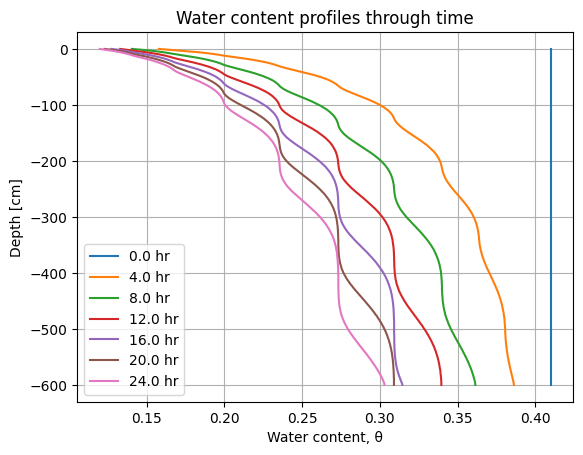

In [16]:
times_to_plot = [0.0, 4.0, 8.0, 12.0, 16.0, 20.0, 24.0]

for t in times_to_plot:
    subset = theta_depth_time[theta_depth_time["Time"] == t]
    plt.plot(subset["theta"], subset["Depth"], label=f"{t} hr")

plt.xlabel("Water content, θ")
plt.ylabel("Depth [cm]")
plt.title("Water content profiles through time")
plt.legend()
plt.grid(True)
plt.show()

### 3. Archie's Law
##### Convert theta(z, t) to theta_bulk(z,t)
Archies Law 

σ=σ(w)​θ^m

Note: σ_bulk (bulk conductivity) = electrical conductivity of entire soil volume. 
[Which will come from HYDRUS or TEM inversion of EC vs Depth profile] 

In [17]:
def theta_to_conductivity(theta, sigma_w, m_archie):
    """ convert volumetric water content to bulk electrical conductivity using simplified Archie's law """
    # sigma_bulk = sigma_w * (theta_s ** m_archie) * (sw ** n_archie) [unused parameters theta_s, sw and n_archie]
    sigma_bulk = sigma_w * theta**m_archie
    return sigma_bulk

sigma_matrix = theta_to_conductivity(theta=theta_matrix, sigma_w=sigma_w, m_archie=m_archie)
sigma_matrix.head()

Time,0.0,4.0,8.0,12.0,16.0,20.0,24.0
Depth,,,,,,,
0.0,0.026253,0.006274,0.005261,0.004845,0.004542,0.004309,0.004147
-2.0,0.026253,0.006806,0.005734,0.005166,0.004856,0.004617,0.004409
-4.0,0.026253,0.007384,0.006132,0.005464,0.005110,0.004861,0.004655
-6.0,0.026253,0.007880,0.006454,0.005786,0.005311,0.005065,0.004861
-8.0,0.026253,0.008288,0.006721,0.006067,0.005561,0.005238,0.005038


In [ ]:
#print("Sigma matrix shape:")
#print(sigma_matrix.shape)

#print("\nSigma matrix preview:")
#print(sigma_matrix.head())

Sigma matrix shape:
(301, 7)

Sigma matrix preview:
Time       0.0       4.0       8.0       12.0      16.0      20.0      24.0
Depth                                                                      
 0.0   0.026253  0.006274  0.005261  0.004845  0.004542  0.004309  0.004147
-2.0   0.026253  0.006806  0.005734  0.005166  0.004856  0.004617  0.004409
-4.0   0.026253  0.007384  0.006132  0.005464  0.005110  0.004861  0.004655
-6.0   0.026253  0.007880  0.006454  0.005786  0.005311  0.005065  0.004861
-8.0   0.026253  0.008288  0.006721  0.006067  0.005561  0.005238  0.005038


### 4. Create a layered model for each time step

In [22]:
def build_layered_model(depth_vector, sigma_profile):
    """
    Convert a conductivity profile into a layered model.

    depth_vector: depths from HYDRUS, usually [0, -2, -4, ...]
    sigma_profile: conductivity values at those depths for one time step
    """

    layers = []

    for i in range(len(depth_vector) - 1):
        layer = {
            "top": depth_vector[i],
            "bottom": depth_vector[i + 1],
            "conductivity": sigma_profile[i]
        }
        layers.append(layer)

    return layers

#### 4.1 Test at a singular time-step 
*remove later

In [21]:
time = 4.0

sigma_profile = sigma_matrix[time].to_numpy()
depth_vector = sigma_matrix.index.to_numpy()

layers_4hr = build_layered_model(depth_vector, sigma_profile)

layers_4hr[:5]

[{'top': np.float64(0.0),
  'bottom': np.float64(-2.0),
  'conductivity': np.float64(0.006274414346375286)},
 {'top': np.float64(-2.0),
  'bottom': np.float64(-4.0),
  'conductivity': np.float64(0.006806179517908706)},
 {'top': np.float64(-4.0),
  'bottom': np.float64(-6.0),
  'conductivity': np.float64(0.007383614291117867)},
 {'top': np.float64(-6.0),
  'bottom': np.float64(-8.0),
  'conductivity': np.float64(0.007879855628119083)},
 {'top': np.float64(-8.0),
  'bottom': np.float64(-10.0),
  'conductivity': np.float64(0.00828844720137614)}]

#### 4.2 At all time steps [This gives us a profile of electrical conductivity as a function of depth over time]

In [23]:
layered_models = {}

for time in sigma_matrix.columns:
    sigma_profile = sigma_matrix[time].to_numpy()
    depth_vector = sigma_matrix.index.to_numpy()

    layered_models[time] = build_layered_model(depth_vector, sigma_profile)

NEXT...... extract one ec profile and one time and determine expected TEM response